# Environment

In [19]:
import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import glasbey

import scanpy as sc
import umap
from harmony import harmonize
from banksy_utils.load_data import display_adata
from banksy_utils.plot_utils import plot_qc_hist
from banksy_utils.filter_utils import filter_cells, filter_hvg
from banksy_utils.umap_pca import pca_umap
from banksy.main import median_dist_to_nearest_neighbour, concatenate_all
from banksy.initialize_banksy import initialize_banksy
from banksy.embed_banksy import generate_banksy_matrix
from banksy.cluster_methods import run_Leiden_partition

sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 0  # errors (0), warnings (1), info (2), hints (3)
plt.rcParams["font.family"] = "Arial"
sns.set_style("white")

import random

# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)

# base
from pathlib import Path
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

mpl.rcdefaults()
%matplotlib inline
CORES = 20
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

# Banksy

## Prep Data

In [9]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "initial_clean.h5ad")
coord_keys = ("x", "y", "SPATIAL")
display_adata(adata)

Displaying adata Object and their attributes
Adata attributes and dimensions:


AnnData object with n_obs × n_vars = 36344 × 19059
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'celltype_colors', 'log1p', 'sample_colors', 'timepoint_colors'
    obsm: 'SPATIAL'
    layers: 'counts', 'logcounts'

Matrix sparsity: 77130406 filled elements (0.11) out of 692680296
max: 2890.0, min: 1.0

Displaying observations (adata.obs)


,sample,nCount_RNA,nFeature_RNA,number_clusters,percent.mt,log10_nCount_RNA,log10_nFeature_RNA,nCount_SCT,nFeature_SCT,SCT_snn_res.0.2,...,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
CU048_01_UCSF_brainstem_rep01_ST_seurat_AAACAAGCAAACTTCC-1,CU048_01_UCSF_brainstem_rep01_ST,5039.0,3046,1,1.051796,3.702344,3.483730,2945.0,2431,1,...,8.021913,5039.0,8.525161,10.577496,16.114308,24.270689,39.988093,53.0,3.988984,1.051796
CU048_01_UCSF_brainstem_rep01_ST_seurat_AAACAAGCAACCCTAT-1,CU048_01_UCSF_brainstem_rep01_ST,5416.0,3079,1,3.305022,3.733679,3.488410,2856.0,2298,0,...,8.032685,5416.0,8.597297,12.998523,18.519202,26.384786,42.208272,179.0,5.192957,3.305022
CU048_01_UCSF_brainstem_rep01_ST_seurat_AAACAAGCAACTATCC-1,CU048_01_UCSF_brainstem_rep01_ST,1926.0,1490,1,2.855659,3.284656,3.173186,1935.0,1490,6,...,7.307202,1926.0,7.563720,12.045691,18.691589,29.075805,48.598131,55.0,4.025352,2.855659
CU048_01_UCSF_brainstem_rep01_ST_seurat_AAACAAGCAAGAACAA-1,CU048_01_UCSF_brainstem_rep01_ST,1436.0,1198,1,0.696379,3.157154,3.078457,1595.0,1198,1,...,7.089243,1436.0,7.270313,11.490251,18.454039,30.501393,51.392758,10.0,2.397895,0.696379
CU048_01_UCSF_brainstem_rep01_ST_seurat_AAACAAGCACATAGAT-1,CU048_01_UCSF_brainstem_rep01_ST,506.0,446,1,0.592885,2.704151,2.649335,1183.0,557,4,...,6.102559,506.0,6.228511,21.739130,31.620553,51.383399,100.000000,3.0,1.386294,0.592885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CU048_04_UCSF_brainstem_rep02_ST_seurat_TTTGTGAGTGCAATAG-1,CU048_04_UCSF_brainstem_rep02_ST,1574.0,1276,1,3.430750,3.197005,3.105851,1677.0,1276,1,...,7.152269,1574.0,7.362011,12.833545,19.758577,31.639136,50.698856,54.0,4.007333,3.430750
CU048_04_UCSF_brainstem_rep02_ST_seurat_TTTGTGAGTGTCCAAT-1,CU048_04_UCSF_brainstem_rep02_ST,6428.0,3375,1,2.955818,3.808076,3.528274,2514.0,1922,0,...,8.124447,6428.0,8.768574,14.281269,20.084007,28.018046,43.512757,190.0,5.252273,2.955818
CU048_04_UCSF_brainstem_rep02_ST_seurat_TTTGTGAGTTGCCTGA-1,CU048_04_UCSF_brainstem_rep02_ST,3175.0,2214,1,2.551181,3.501744,3.345178,2787.0,2210,1,...,7.703008,3175.0,8.063378,9.952756,15.905512,25.354331,44.346457,81.0,4.406719,2.551181
CU048_04_UCSF_brainstem_rep02_ST_seurat_TTTGTGAGTTGTTTGA-1,CU048_04_UCSF_brainstem_rep02_ST,12451.0,4341,1,2.248815,4.095204,3.637590,2416.0,1650,7,...,8.376090,12451.0,9.429637,16.376195,23.371617,32.117902,48.028271,280.0,5.638355,2.248815


Displaying variables (adata.var)


,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
Xkr4,False,6599,0.236463,0.212255,81.842945,8594.0,9.058936
Rp1,False,25,0.000715,0.000715,99.931213,26.0,3.295837
Sox17,False,1085,0.053269,0.051898,97.014638,1936.0,7.568896
Lypla1,False,5040,0.186303,0.170842,86.132512,6771.0,8.820552
Tcea1,False,10750,0.457930,0.377017,70.421528,16643.0,9.719805
...,...,...,...,...,...,...,...
mt-Nd4,True,20631,1.664236,0.979917,43.234096,60485.0,11.010167
mt-Nd5,True,30162,6.290062,1.986512,17.009685,228606.0,12.339760
mt-Nd6,True,23142,2.216900,1.168418,36.325116,80571.0,11.296906
mt-Cytb,True,34252,13.355795,2.664154,5.756108,485403.0,13.092737


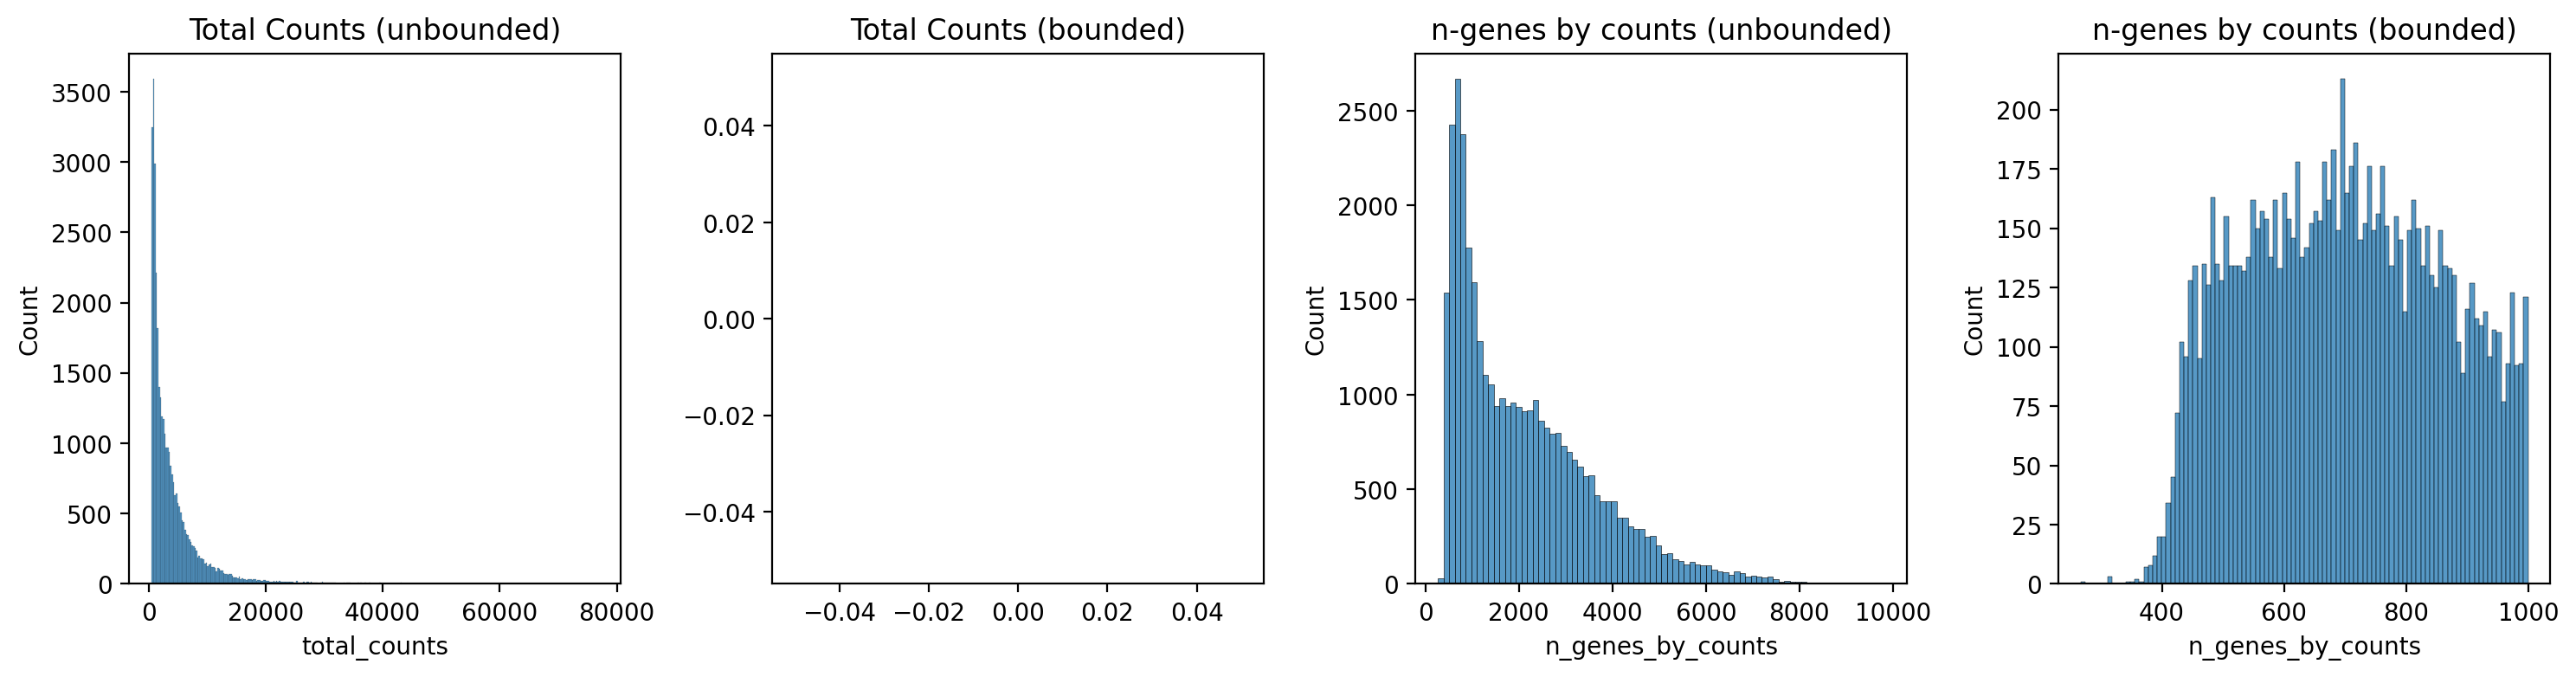

In [10]:
hist_bin_options = ["auto", 80, 80, 100]

plot_qc_hist(
    adata,
    total_counts_cutoff=300,  # for visualization
    n_genes_high_cutoff=1000,  # for visualization
    n_genes_low_cutoff=0,  # for visualization
    bin_options=hist_bin_options,
)

## Filter & Preprocess

In [11]:
adata.X = adata.layers["counts"].copy()

# Filter hvgs
adata, adata_allgenes = filter_hvg(adata, n_top_genes=2000, flavor="seurat")

--- Normalized and log-transformed data -----
Displaying max and min of Dataset
Max: 7.969357742016346, Min: 0.0

Displaying dataset after filtering by HVG
View of AnnData object with n_obs × n_vars = 36344 × 2000
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'celltype_colors', 'log1p', 'sample_colors', 'timepoint_colors'
    obsm: 'SPATIAL'
    layers: 'counts', 'logcounts'


## Run Banksy

In [17]:
# Initialization params
plot_graph_weights = True
k_geom = 15  # only for fixed type
max_m = 1  # azumithal transform up to kth order
nbr_weight_decay = "scaled_gaussian"  # can also be "reciprocal", "uniform" or "ranked"
lambda_list = [0.2, 0.5, 0.8]  # list of lambda parameters

# Find median distance to closest neighbours, the median distance will be `sigma`
nbrs = median_dist_to_nearest_neighbour(adata, key=coord_keys[2])
banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,
    nbr_weight_decay=nbr_weight_decay,
    plt_edge_hist=False,
    plt_nbr_weights=False,
    plt_agf_angles=False,
    plt_theta=False,
)

# define spatial information
banksy_dict, banksy_matrix = generate_banksy_matrix(
    adata, banksy_dict, lambda_list, max_m
)

# define nonspatial information
banksy_dict["nonspatial"] = {
    # Here we simply append the nonspatial matrix (adata.X) to obtain the nonspatial clustering results
    0.0: {
        "adata": concatenate_all([adata.X], 0, adata=adata),
    }
}


Median distance to closest cell = 17.469010400585695

---- Ran median_dist_to_nearest_neighbour in 0.25 s ----


Median distance to closest cell = 17.469010400585695

---- Ran median_dist_to_nearest_neighbour in 0.19 s ----

---- Ran generate_spatial_distance_graph in 0.38 s ----

---- Ran row_normalize in 0.14 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 1.49 s ----

---- Ran generate_spatial_distance_graph in 0.46 s ----

---- Ran theta_from_spatial_graph in 0.62 s ----

---- Ran row_normalize in 0.13 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 2.56 s ----

Runtime Nov-04-2025-11-57

2000 genes to be analysed:
Gene List:
Index(['Sox17', 'Vxn', 'Sulf1', 'Prdm14', 'Trpa1', 'Kcnb2', 'Jph1', 'Tfap2b',
       'Khdc1a', 'Kcnq5',
       ...
       'Irs4', 'Htr2c', 'Alas2', 'Ptchd1', 'Adgrg2', 'Grpr', 'Ap1s2', 'Bmx',
       'Glra2', 'Frmpd4'],
      dtype='object', length=2000)

Check if X contains only finite (non-NAN) values
Decay Type: scaled_gaussian
Weights Objec

Current decay types: ['scaled_gaussian', 'nonspatial']

Reducing dims of dataset in (Index = scaled_gaussian, lambda = 0.2)

Setting the total number of PC = 50
Original shape of matrix: (36344, 6000)
Reduced shape of matrix: (36344, 50)
------------------------------------------------------------
min_value = -198.8160192192994, mean = 6.234257857670613e-16, max = 419.0395369326633

Conducting UMAP and adding embeddings to adata.obsm["reduced_pc_50_umap"]
UMAP embedding
------------------------------------------------------------
shape: (36344, 2)


AxisArrays with keys: reduced_pc_50, reduced_pc_50_umap

Reducing dims of dataset in (Index = scaled_gaussian, lambda = 0.5)

Setting the total number of PC = 50
Original shape of matrix: (36344, 6000)
Reduced shape of matrix: (36344, 50)
------------------------------------------------------------
min_value = -144.28624148517682, mean = 4.128866397897192e-16, max = 318.42255063593075

Conducting UMAP and adding embeddings to adata.obsm["re

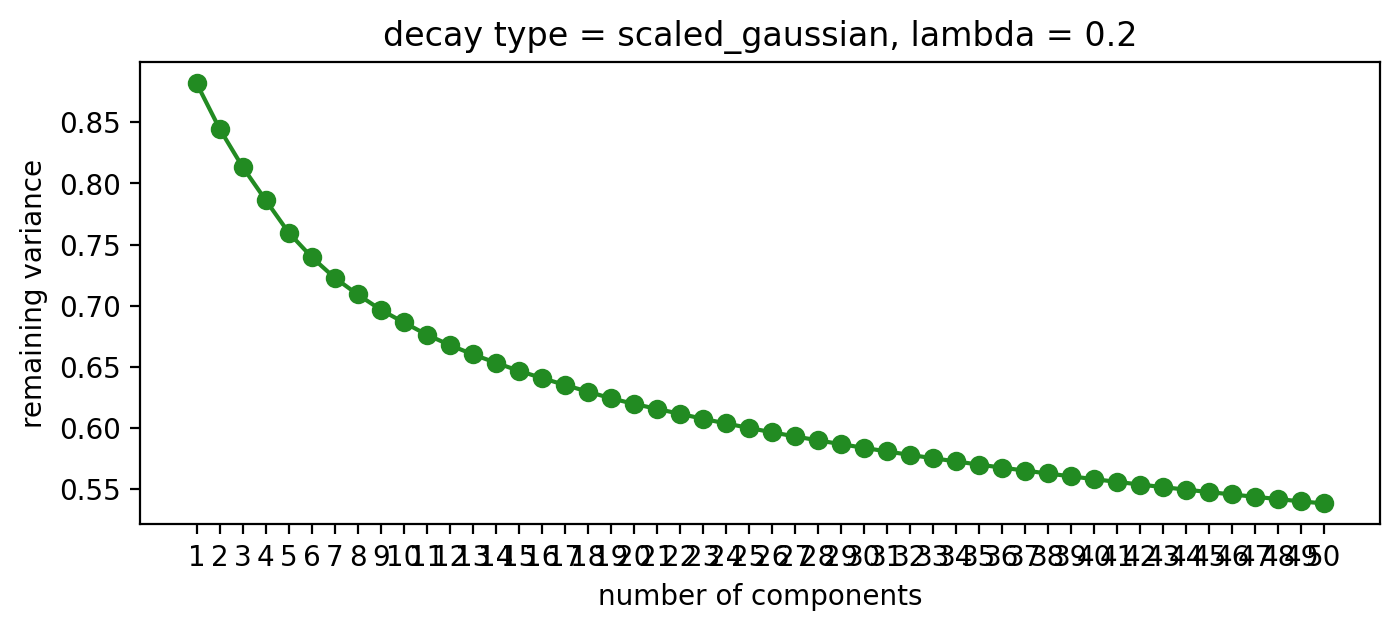

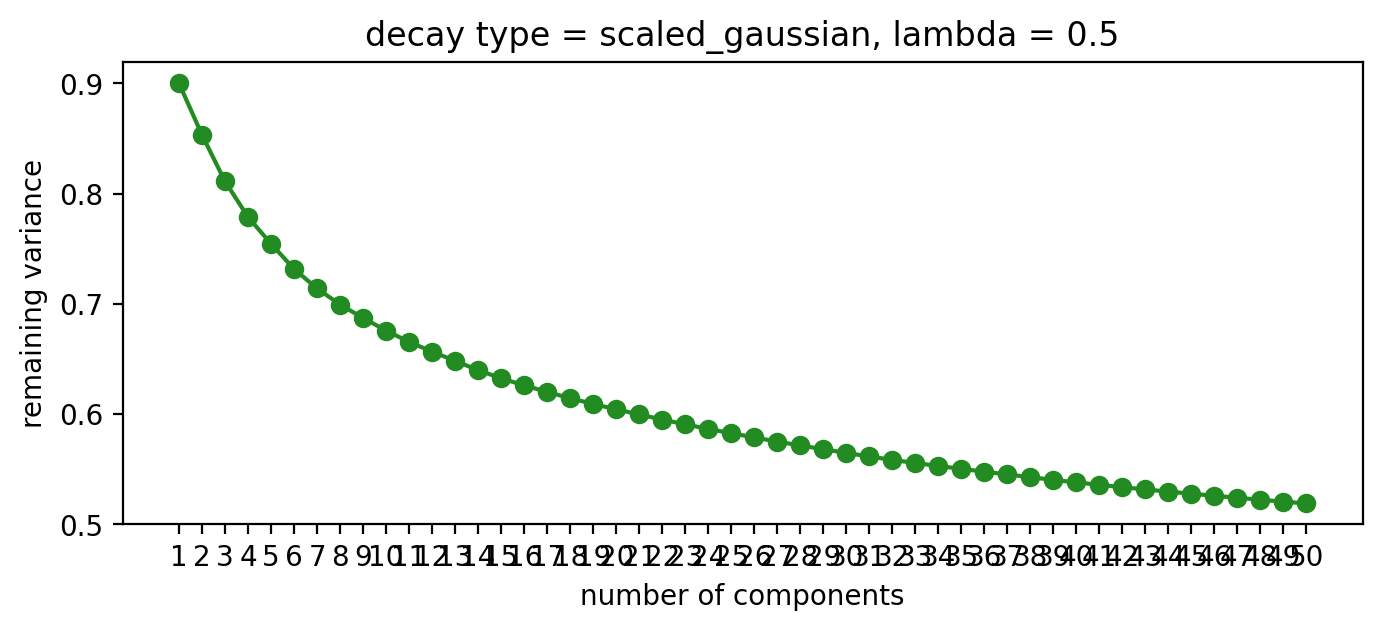

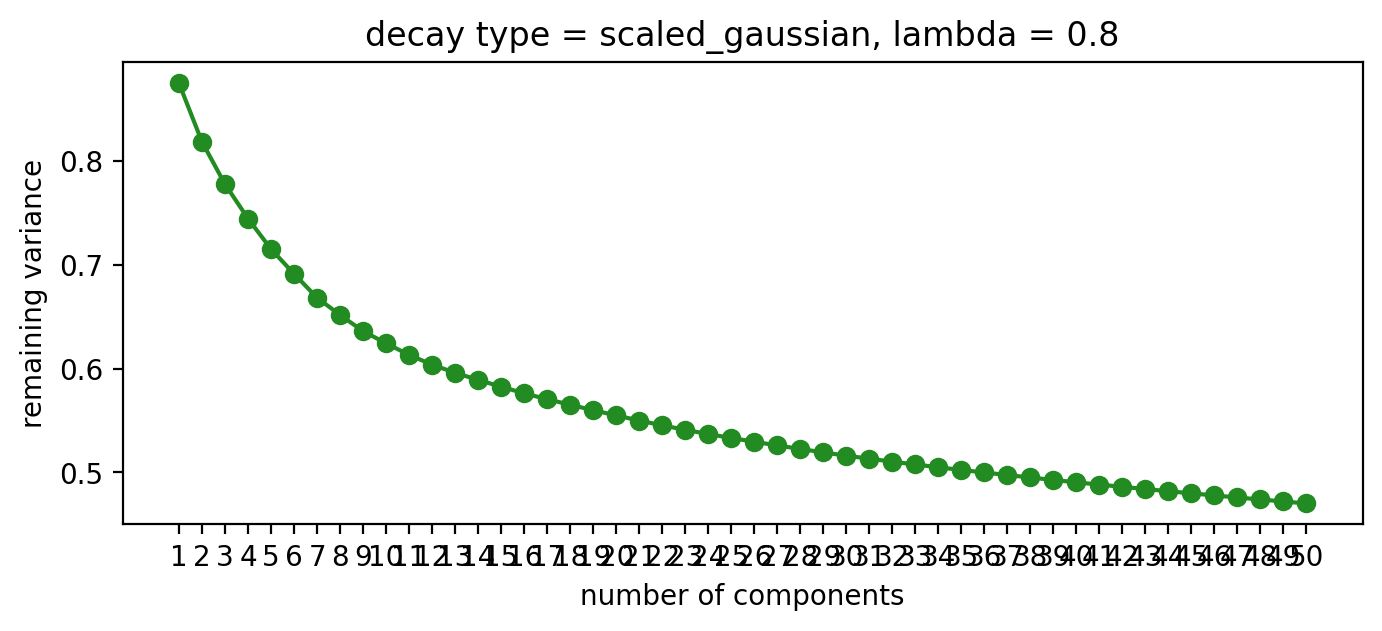

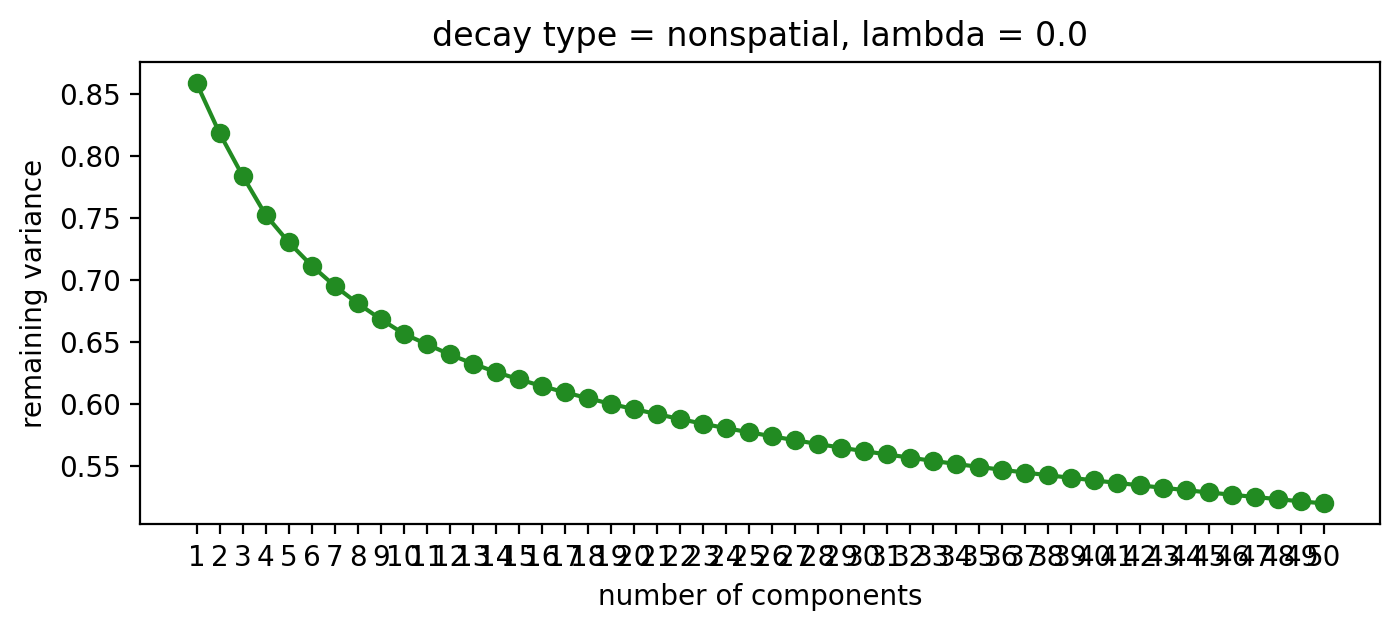

In [18]:
batch_key = "Identifier"
pca_dims = [50]

pca_umap(banksy_dict, pca_dims=pca_dims, add_umap=True)

In [ ]:
for pca_dim in pca_dims:
    # Run Harmony on PCA
    Z = harmonize(
        banksy_dict[nbr_weight_decay][0.2]["adata"].obsm[f"reduced_pc_{pca_dim}"],
        banksy_dict[nbr_weight_decay][0.2]["adata"].obs,
        batch_key=batch_key,
    )

    print(
        f'Replacing adata.obsm["reduced_pc_{pca_dim}"] with harmony corrected embeddings.'
    )
    banksy_dict[nbr_weight_decay][0.2]["adata"].obsm[f"reduced_pc_{pca_dim}"] = Z

    # Run UMAP
    reducer = umap.UMAP(transform_seed=42)
    umap_embedding = reducer.fit_transform(Z)
    banksy_dict[nbr_weight_decay][0.2]["adata"].obsm[
        f"reduced_pc_{pca_dim}_umap"
    ] = umap_embedding

In [ ]:
from banksy.cluster_methods import run_Leiden_partition

resolutions = [0.3, 0.7]  # clustering resolutions for UMAP

results_df, max_num_labels = run_Leiden_partition(
    banksy_dict,
    resolutions,
    num_nn=50,
    num_iterations=-1,
    partition_seed=seed,
    match_labels=True,
)

In [ ]:
from banksy.plot_banksy import plot_results

c_map = "tab20"  # specify color map
weights_graph = banksy_dict["scaled_gaussian"]["weights"][0]

plot_results(
    results_df,
    weights_graph,
    c_map,
    match_labels=True,
    coord_keys=coord_keys,
    max_num_labels=max_num_labels,
    save_path="outs",
    save_fig=False,  # save the spatial map of all clusters
    save_seperate_fig=False,  # save the figure of all clusters plotted seperately
)

In [ ]:
# import pickle
# filename = DATADIR / "processed" / "spatial" / "analysis" / "banksy_results.pkl"

# with open(filename, 'wb') as file:
#     pickle.dump((banksy_dict, results_df, max_num_labels), file)

# Plot

In [32]:
import pickle

adata = sc.read_h5ad(DATADIR / "processed" / "external" / "initial_clean.h5ad")
filename = DATADIR / "processed" / "external" / "banksy" / "banksy_results.pkl"
batch_key = "batch"

with open(filename, "rb") as file:
    banksy_dict, results_df, max_num_labels = pickle.load(file)

results_df.iloc[:, results_df.columns != "adata"]

,decay,lambda_param,num_pcs,resolution,num_labels,labels,relabeled
nonspatial_pc30_nc0.00_r0.30,nonspatial,0.0,30,0.3,16,"Label object:\nNumber of labels: 16, number of...","Label object:\nNumber of labels: 16, number of..."
nonspatial_pc30_nc0.00_r0.40,nonspatial,0.0,30,0.4,17,"Label object:\nNumber of labels: 17, number of...","Label object:\nNumber of labels: 17, number of..."
nonspatial_pc30_nc0.00_r0.50,nonspatial,0.0,30,0.5,21,"Label object:\nNumber of labels: 21, number of...","Label object:\nNumber of labels: 21, number of..."
nonspatial_pc30_nc0.00_r0.60,nonspatial,0.0,30,0.6,22,"Label object:\nNumber of labels: 22, number of...","Label object:\nNumber of labels: 22, number of..."
nonspatial_pc30_nc0.00_r0.70,nonspatial,0.0,30,0.7,22,"Label object:\nNumber of labels: 22, number of...","Label object:\nNumber of labels: 22, number of..."
nonspatial_pc30_nc0.00_r0.80,nonspatial,0.0,30,0.8,25,"Label object:\nNumber of labels: 25, number of...","Label object:\nNumber of labels: 25, number of..."
nonspatial_pc30_nc0.00_r0.90,nonspatial,0.0,30,0.9,26,"Label object:\nNumber of labels: 26, number of...","Label object:\nNumber of labels: 26, number of..."
nonspatial_pc30_nc0.00_r1.00,nonspatial,0.0,30,1.0,27,"Label object:\nNumber of labels: 27, number of...","Label object:\nNumber of labels: 27, number of..."
scaled_gaussian_pc30_nc0.20_r0.30,scaled_gaussian,0.2,30,0.3,14,"Label object:\nNumber of labels: 14, number of...","Label object:\nNumber of labels: 14, number of..."
scaled_gaussian_pc30_nc0.20_r0.40,scaled_gaussian,0.2,30,0.4,16,"Label object:\nNumber of labels: 16, number of...","Label object:\nNumber of labels: 16, number of..."


In [ ]:
for l in results_df["lambda_param"].unique():
    result = results_df[results_df["lambda_param"] == l].adata[0]
    for col in result.obs:
        if "label" in col:
            adata.obs["BANKSY_" + col] = result.obs[col]
adata.obs.columns

Index(['batch', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt',
       'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT',
       'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'sample',
       'BANKSY_labels_nonspatial_pc30_nc0.00_r0.30',
       'BANKSY_labels_nonspatial_pc30_nc0.00_r0.40',
       'BANKSY_labels_nonspatial_pc30_nc0.00_r0.50',
       'BANKSY_labels_nonspatial_pc30_nc0.00_r0.60',
       'BANKSY_labels_nonspatial_pc30_nc0.00_r0.70',
       'BANKSY_labels_nonspatial_pc30_nc0.00_r0.80',
       'BANKSY_labels_nonspatial_pc30_nc0.00_r0.90',
       'BANKSY_labels_nonspatial_pc30_nc0.00_r1.00',
       'BANKSY_labels_s

In [ ]:
# version = "scaled_gaussian_pc30_nc0.50_r0.30"
# clusters_name = f"BANKSY_labels_{version}"
banksy_nh = [col for col in adata.obs if "BANKSY" in col]


def order_obs(adata, col, order):
    adata.obs[col] = pd.Categorical(adata.obs[col], categories=order, ordered=True)
    return


# order_obs(adata, clusters_name, adata.obs[clusters_name].cat.categories.astype(int).sort_values().astype(str))
# palette = glasbey.create_palette(palette_size=len(adata.obs[clusters_name].unique()))

f, ax = plt.subplots(
    len(banksy_nh), 1, figsize=(18, 6 * len(banksy_nh)), layout="constrained"
)
for n, col in enumerate(banksy_nh):
    sc.pl.spatial(
        adata,
        basis="SPATIAL",
        spot_size=50,
        color=col,
        ax=ax[n],
        frameon=False,
        palette=glasbey.create_palette(
            palette_size=len(adata.obs[col].unique()),
        ),
        show=False,
    )

# # single sample for plotting
# sample1 = adata[adata.obs[batch_key] == adata.obs[batch_key].unique()[0]]
# print(f"total clusters: {len(adata.obs[clusters_name].unique())}")

/mnt/DATA/home/ethung/miniconda3/envs/banksy/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


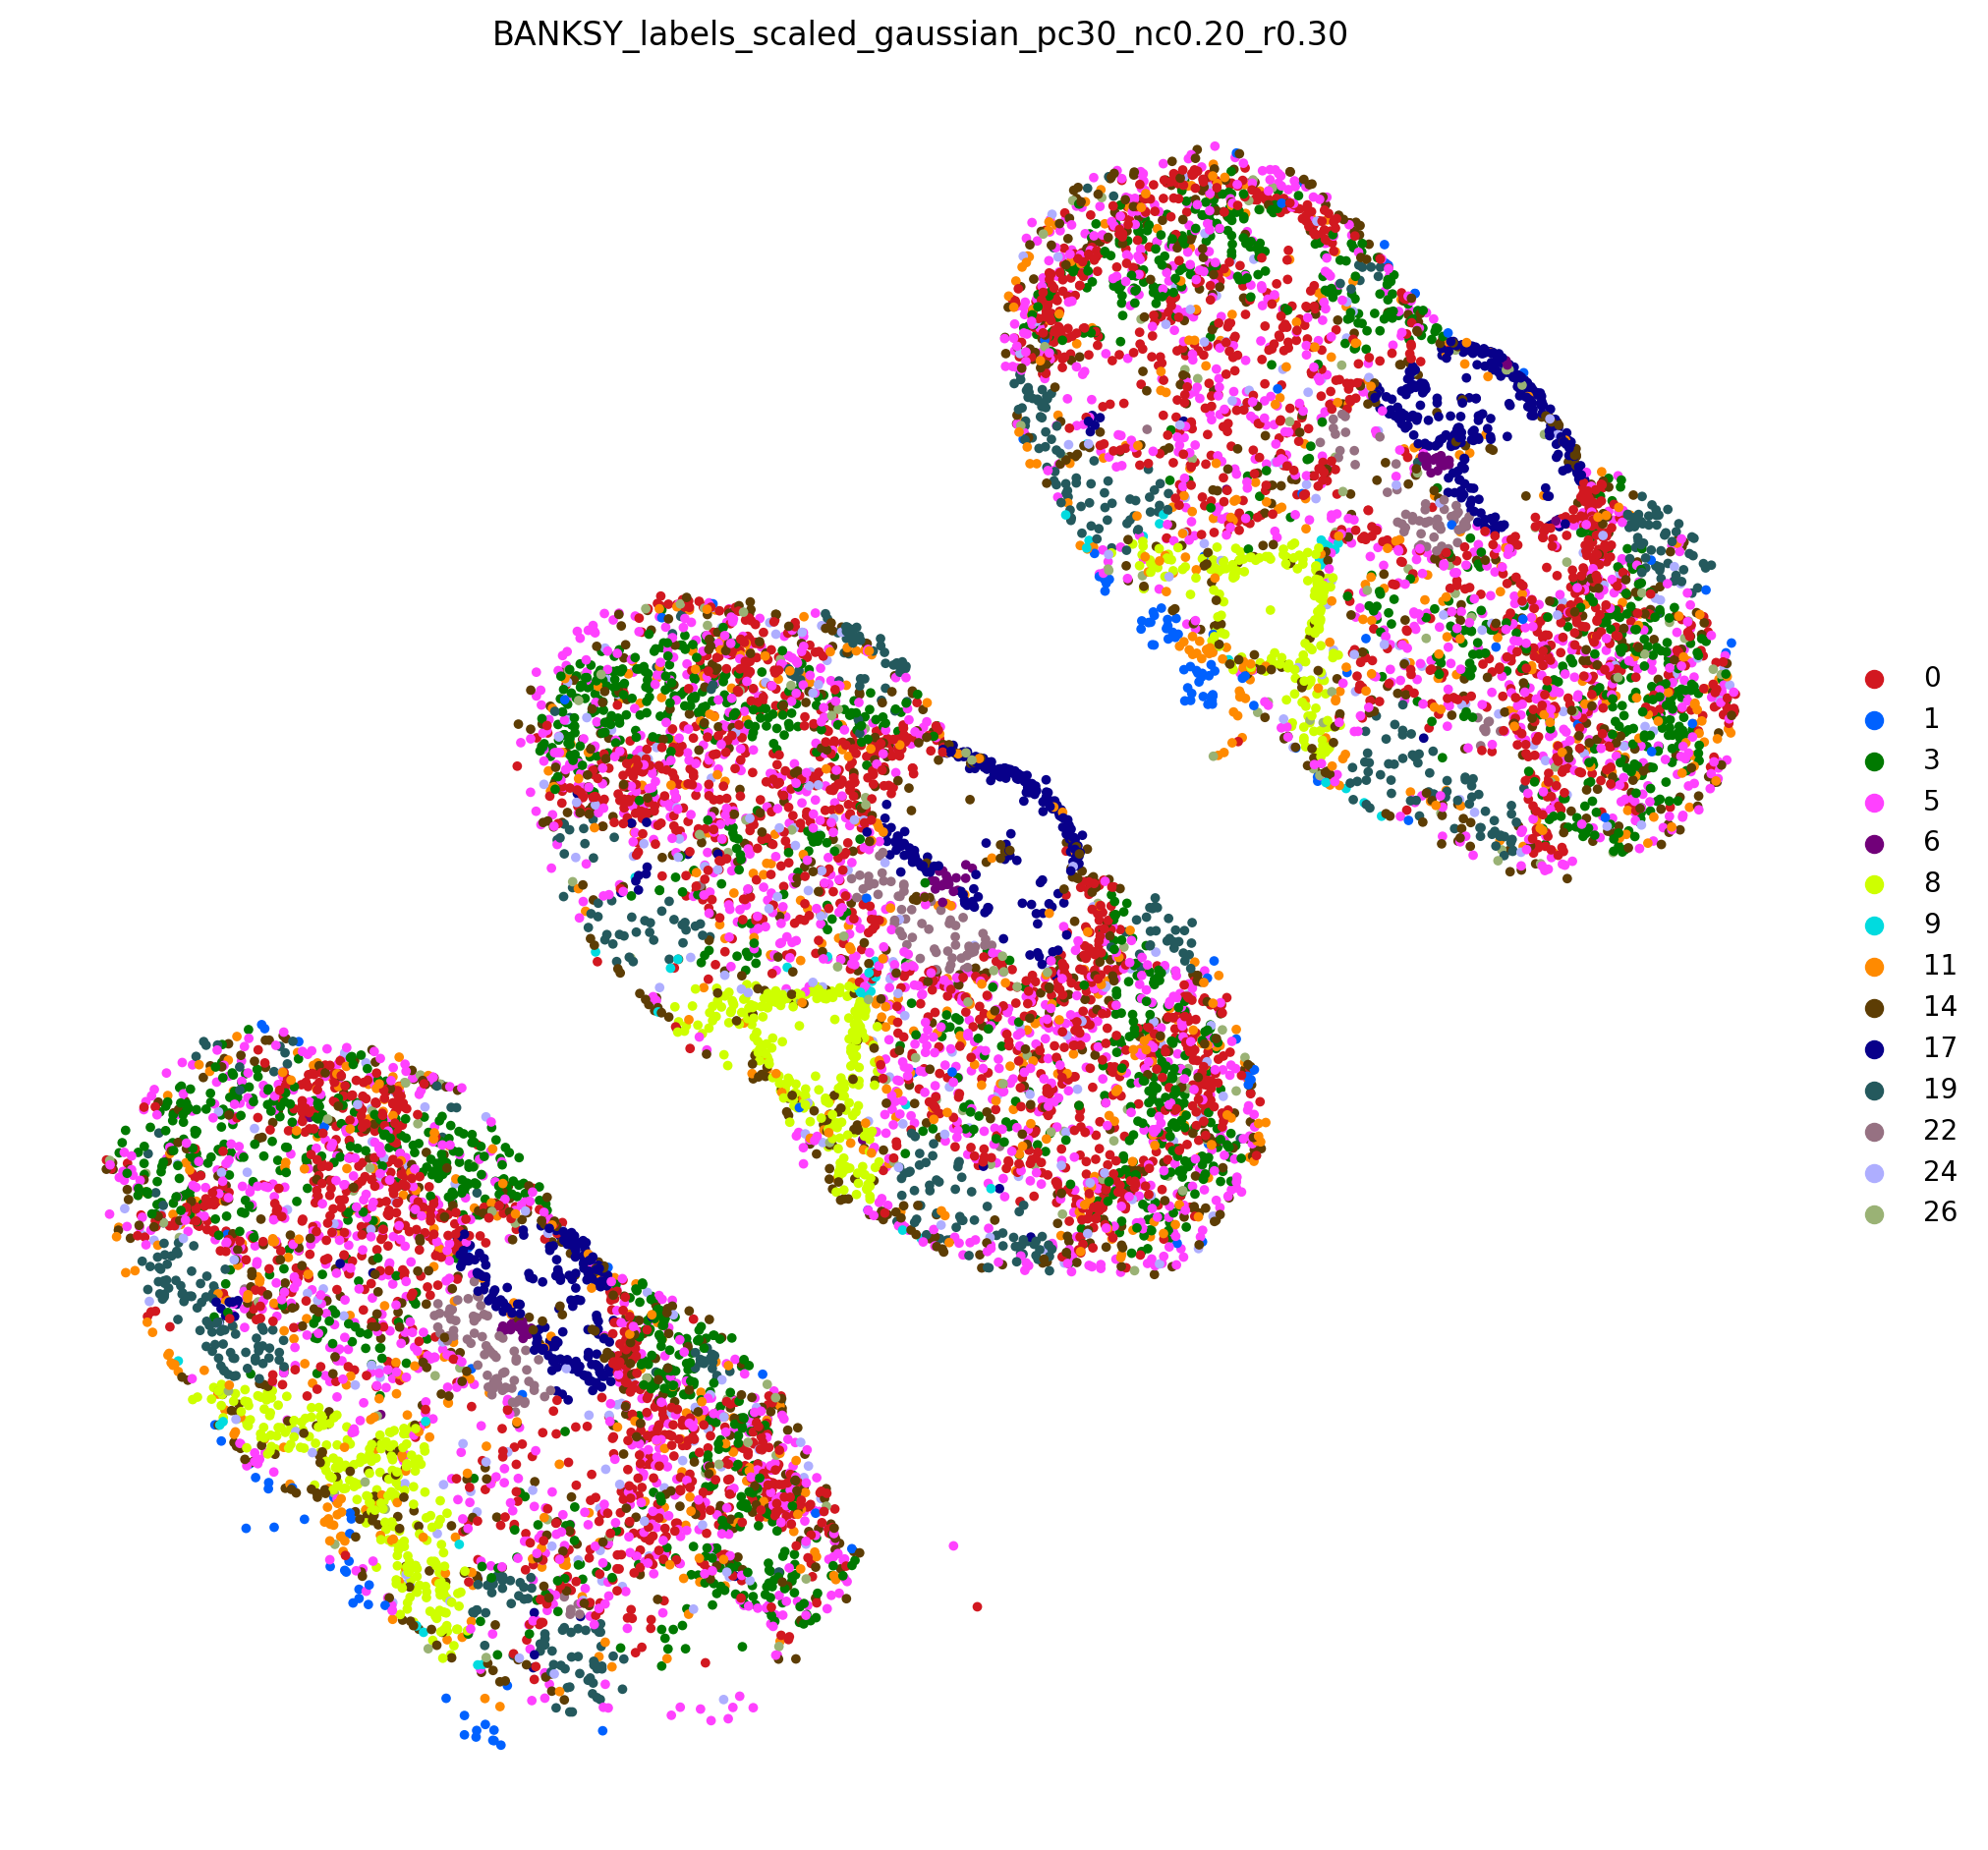

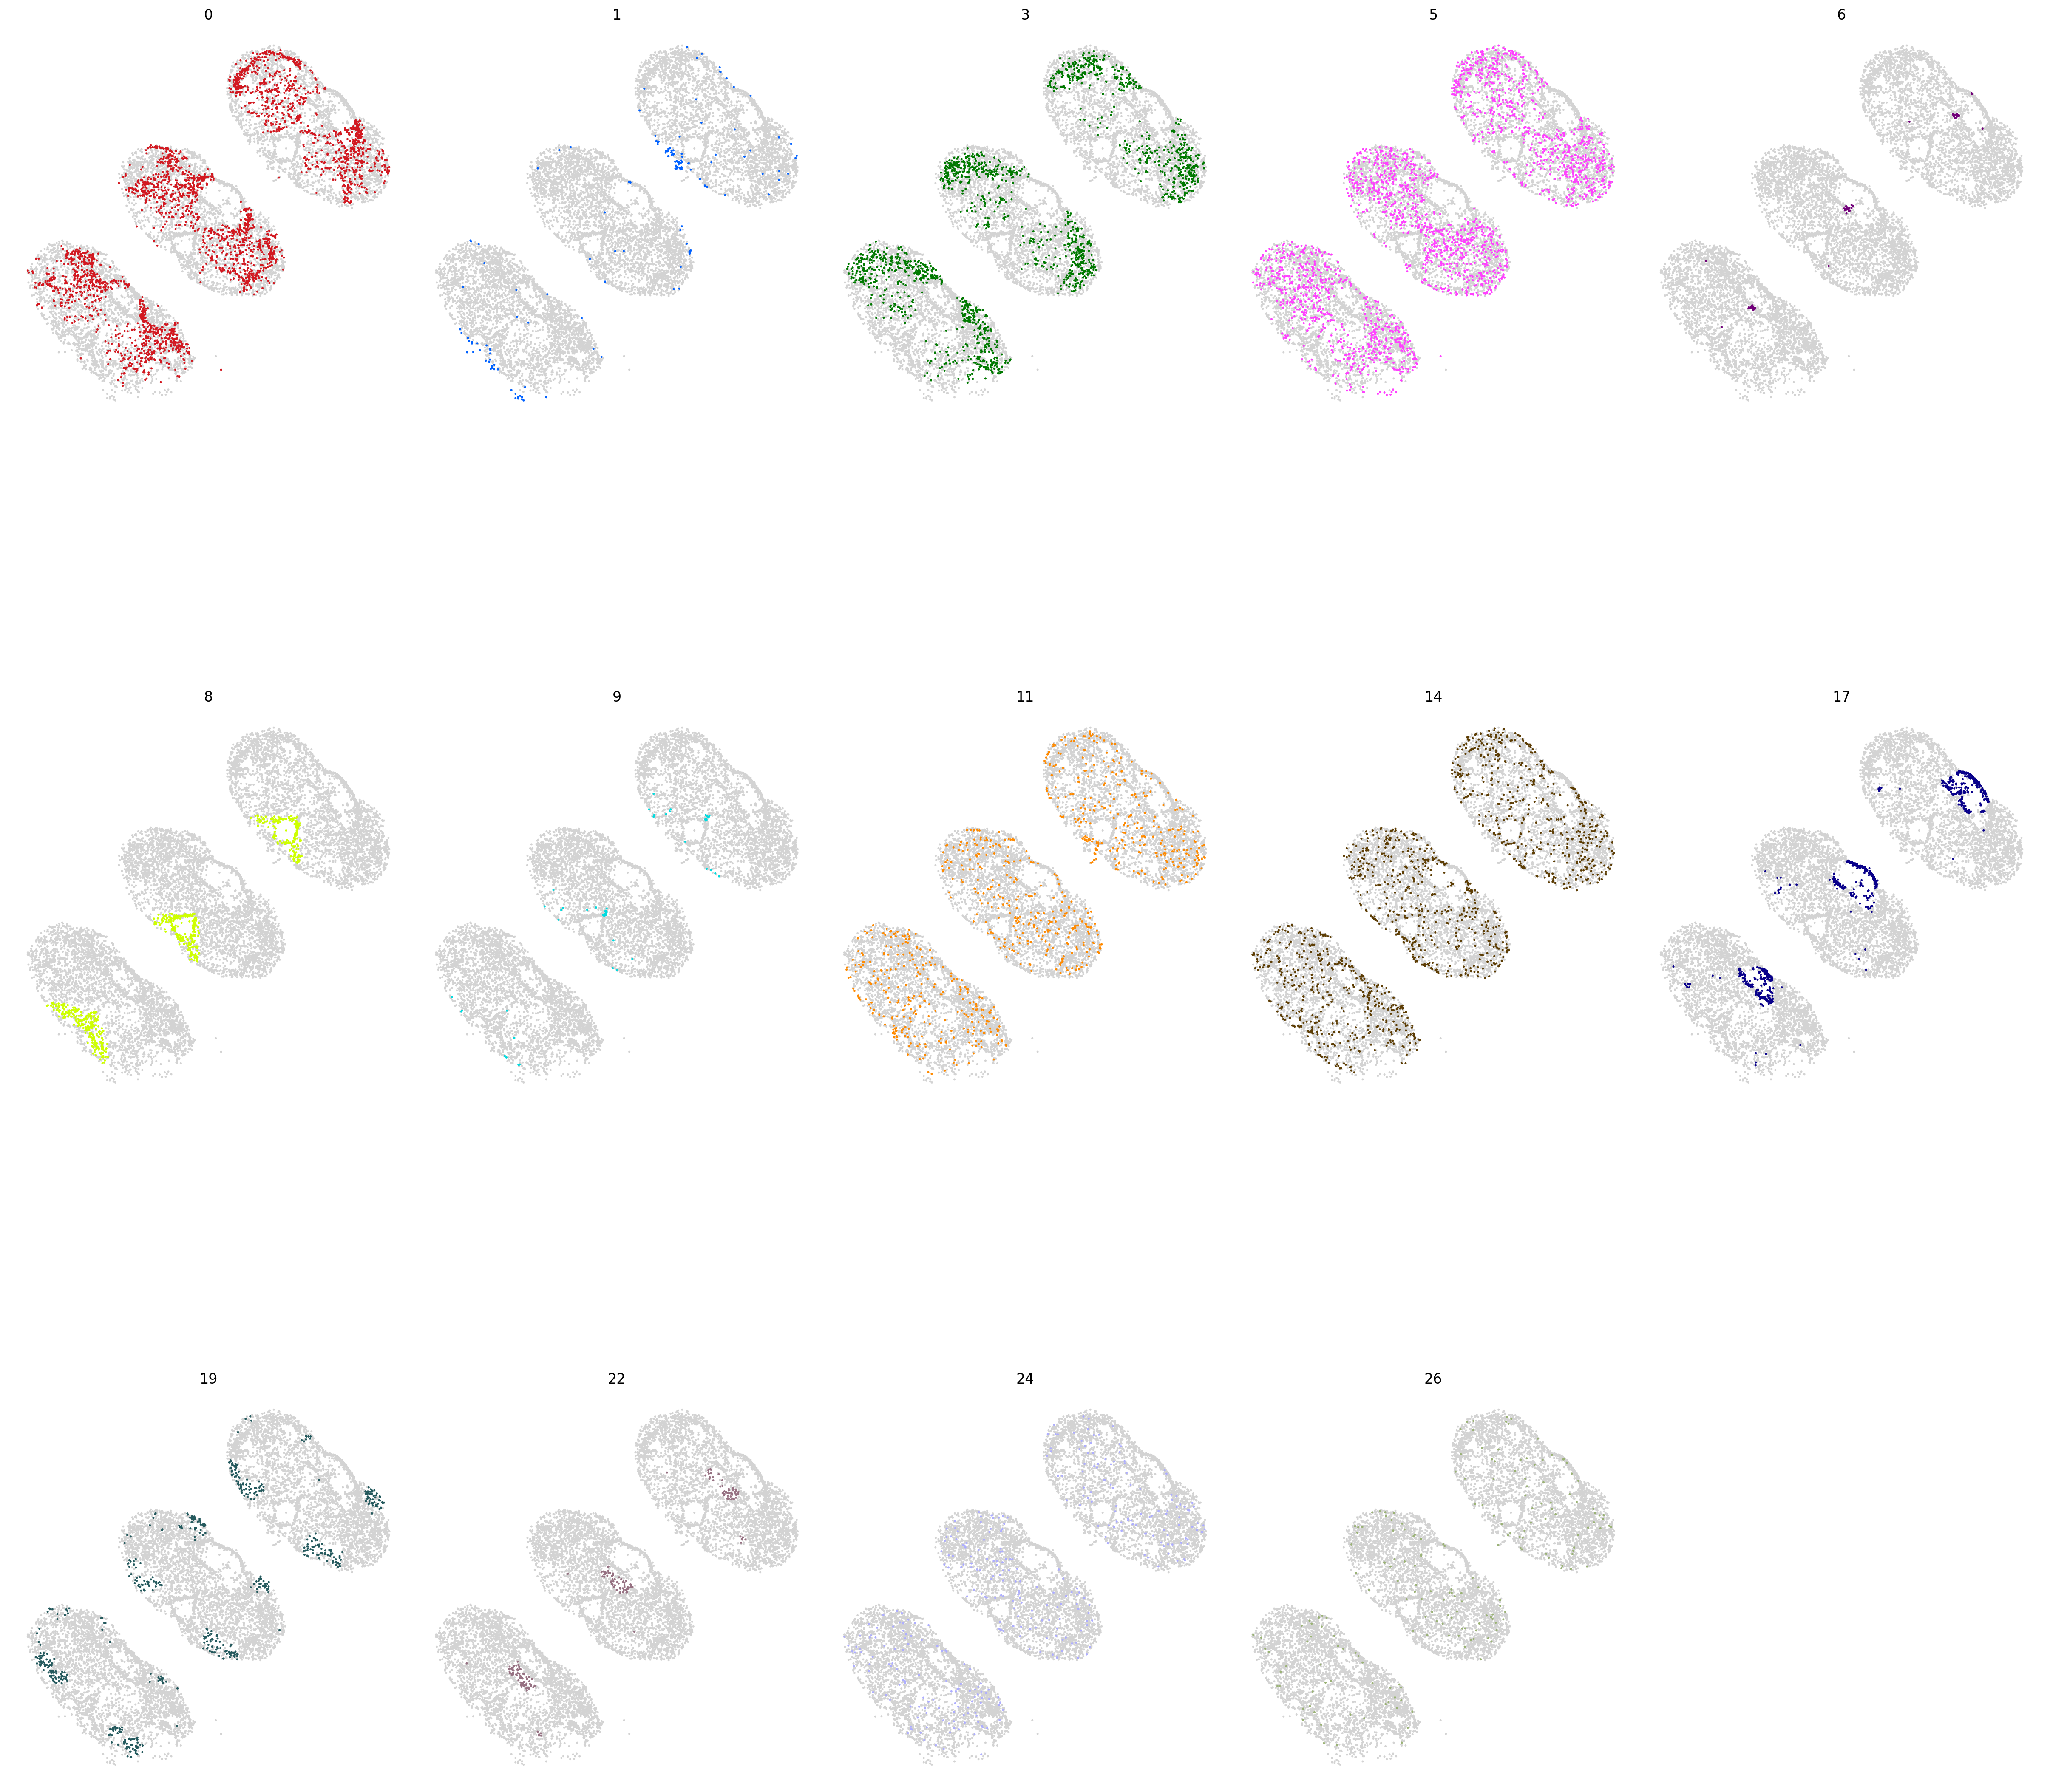

In [111]:
f, ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")
sc.pl.spatial(
    sample1,
    basis="SPATIAL",
    spot_size=50,
    color=clusters_name,
    ax=ax,
    frameon=False,
    palette=palette,
)

f, axs = plt.subplots(3, 5, figsize=(24, 24), layout="constrained")
axs = axs.flatten()
for n, i in enumerate(sample1.obs[clusters_name].cat.categories):
    sample1.obs["dummy"] = (sample1.obs[clusters_name] == i).replace(
        {True: i, False: None}
    )

    sc.pl.spatial(
        sample1,
        basis="SPATIAL",
        spot_size=50,
        color="dummy",
        ax=axs[n],
        frameon=False,
        show=False,
        title=i,
        legend_loc="none",
        palette=[palette[n]],
    )

axs[-1].remove()

In [105]:
adata

AnnData object with n_obs × n_vars = 36344 × 19059
    obs: 'batch', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.30', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.40', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.50', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.60', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.70', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.80', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.90', 'BANKSY_labels_nonspatial_pc30_nc0.00_r1.00', 'BANKSY_labels_scaled_gaussian_pc30_nc0.20_r0.30', 'BANKSY_labels_scaled_ga

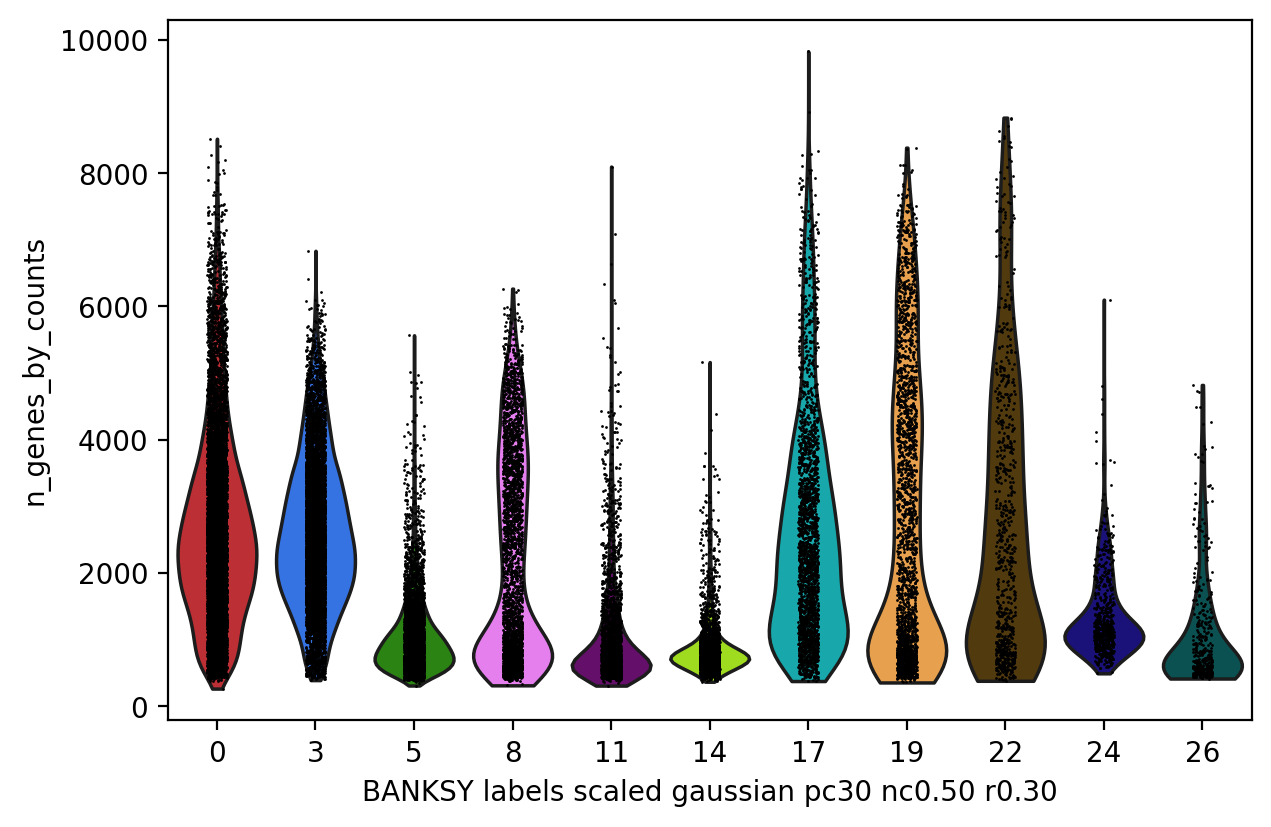

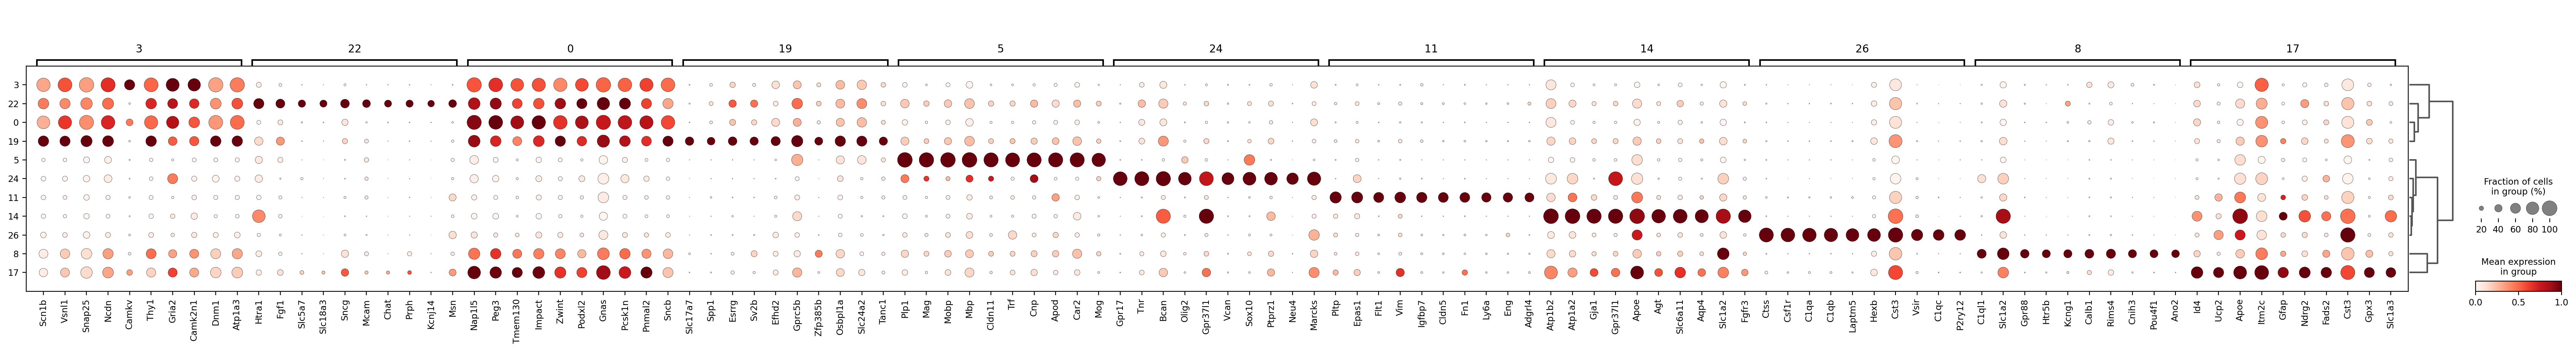

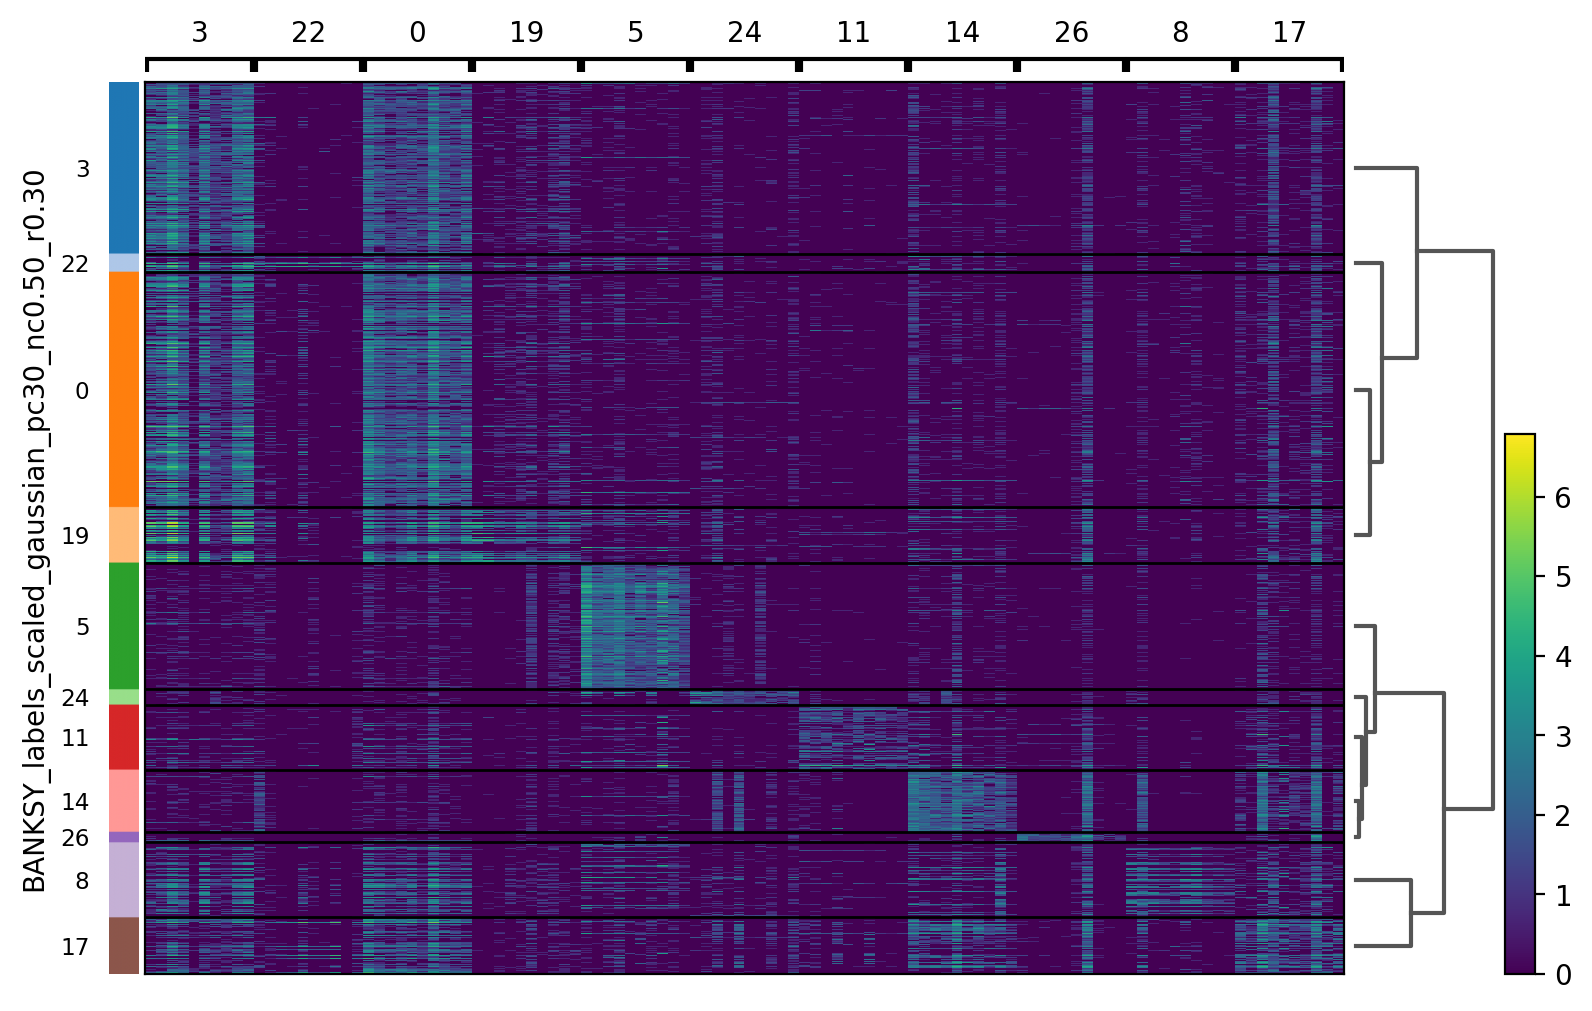

In [107]:
de_key = "DEGs"
runDEGs = False

sc.pl.violin(adata, "n_genes_by_counts", groupby=clusters_name)

if runDEGs is True:
    sc.tl.rank_genes_groups(
        adata,
        groupby=clusters_name,
        key_added=de_key,
        use_raw=False,
        layer="logcounts",
        method="wilcoxon",
    )

sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby=clusters_name,
    key=de_key,
    standard_scale="var",
    n_genes=10,
    # min_logfoldchange=2,
    # ax=ax,
)

sc.pl.rank_genes_groups_heatmap(
    adata, key=de_key, groupby=[clusters_name], layer="logcounts"
)